Accuracy: 1.0


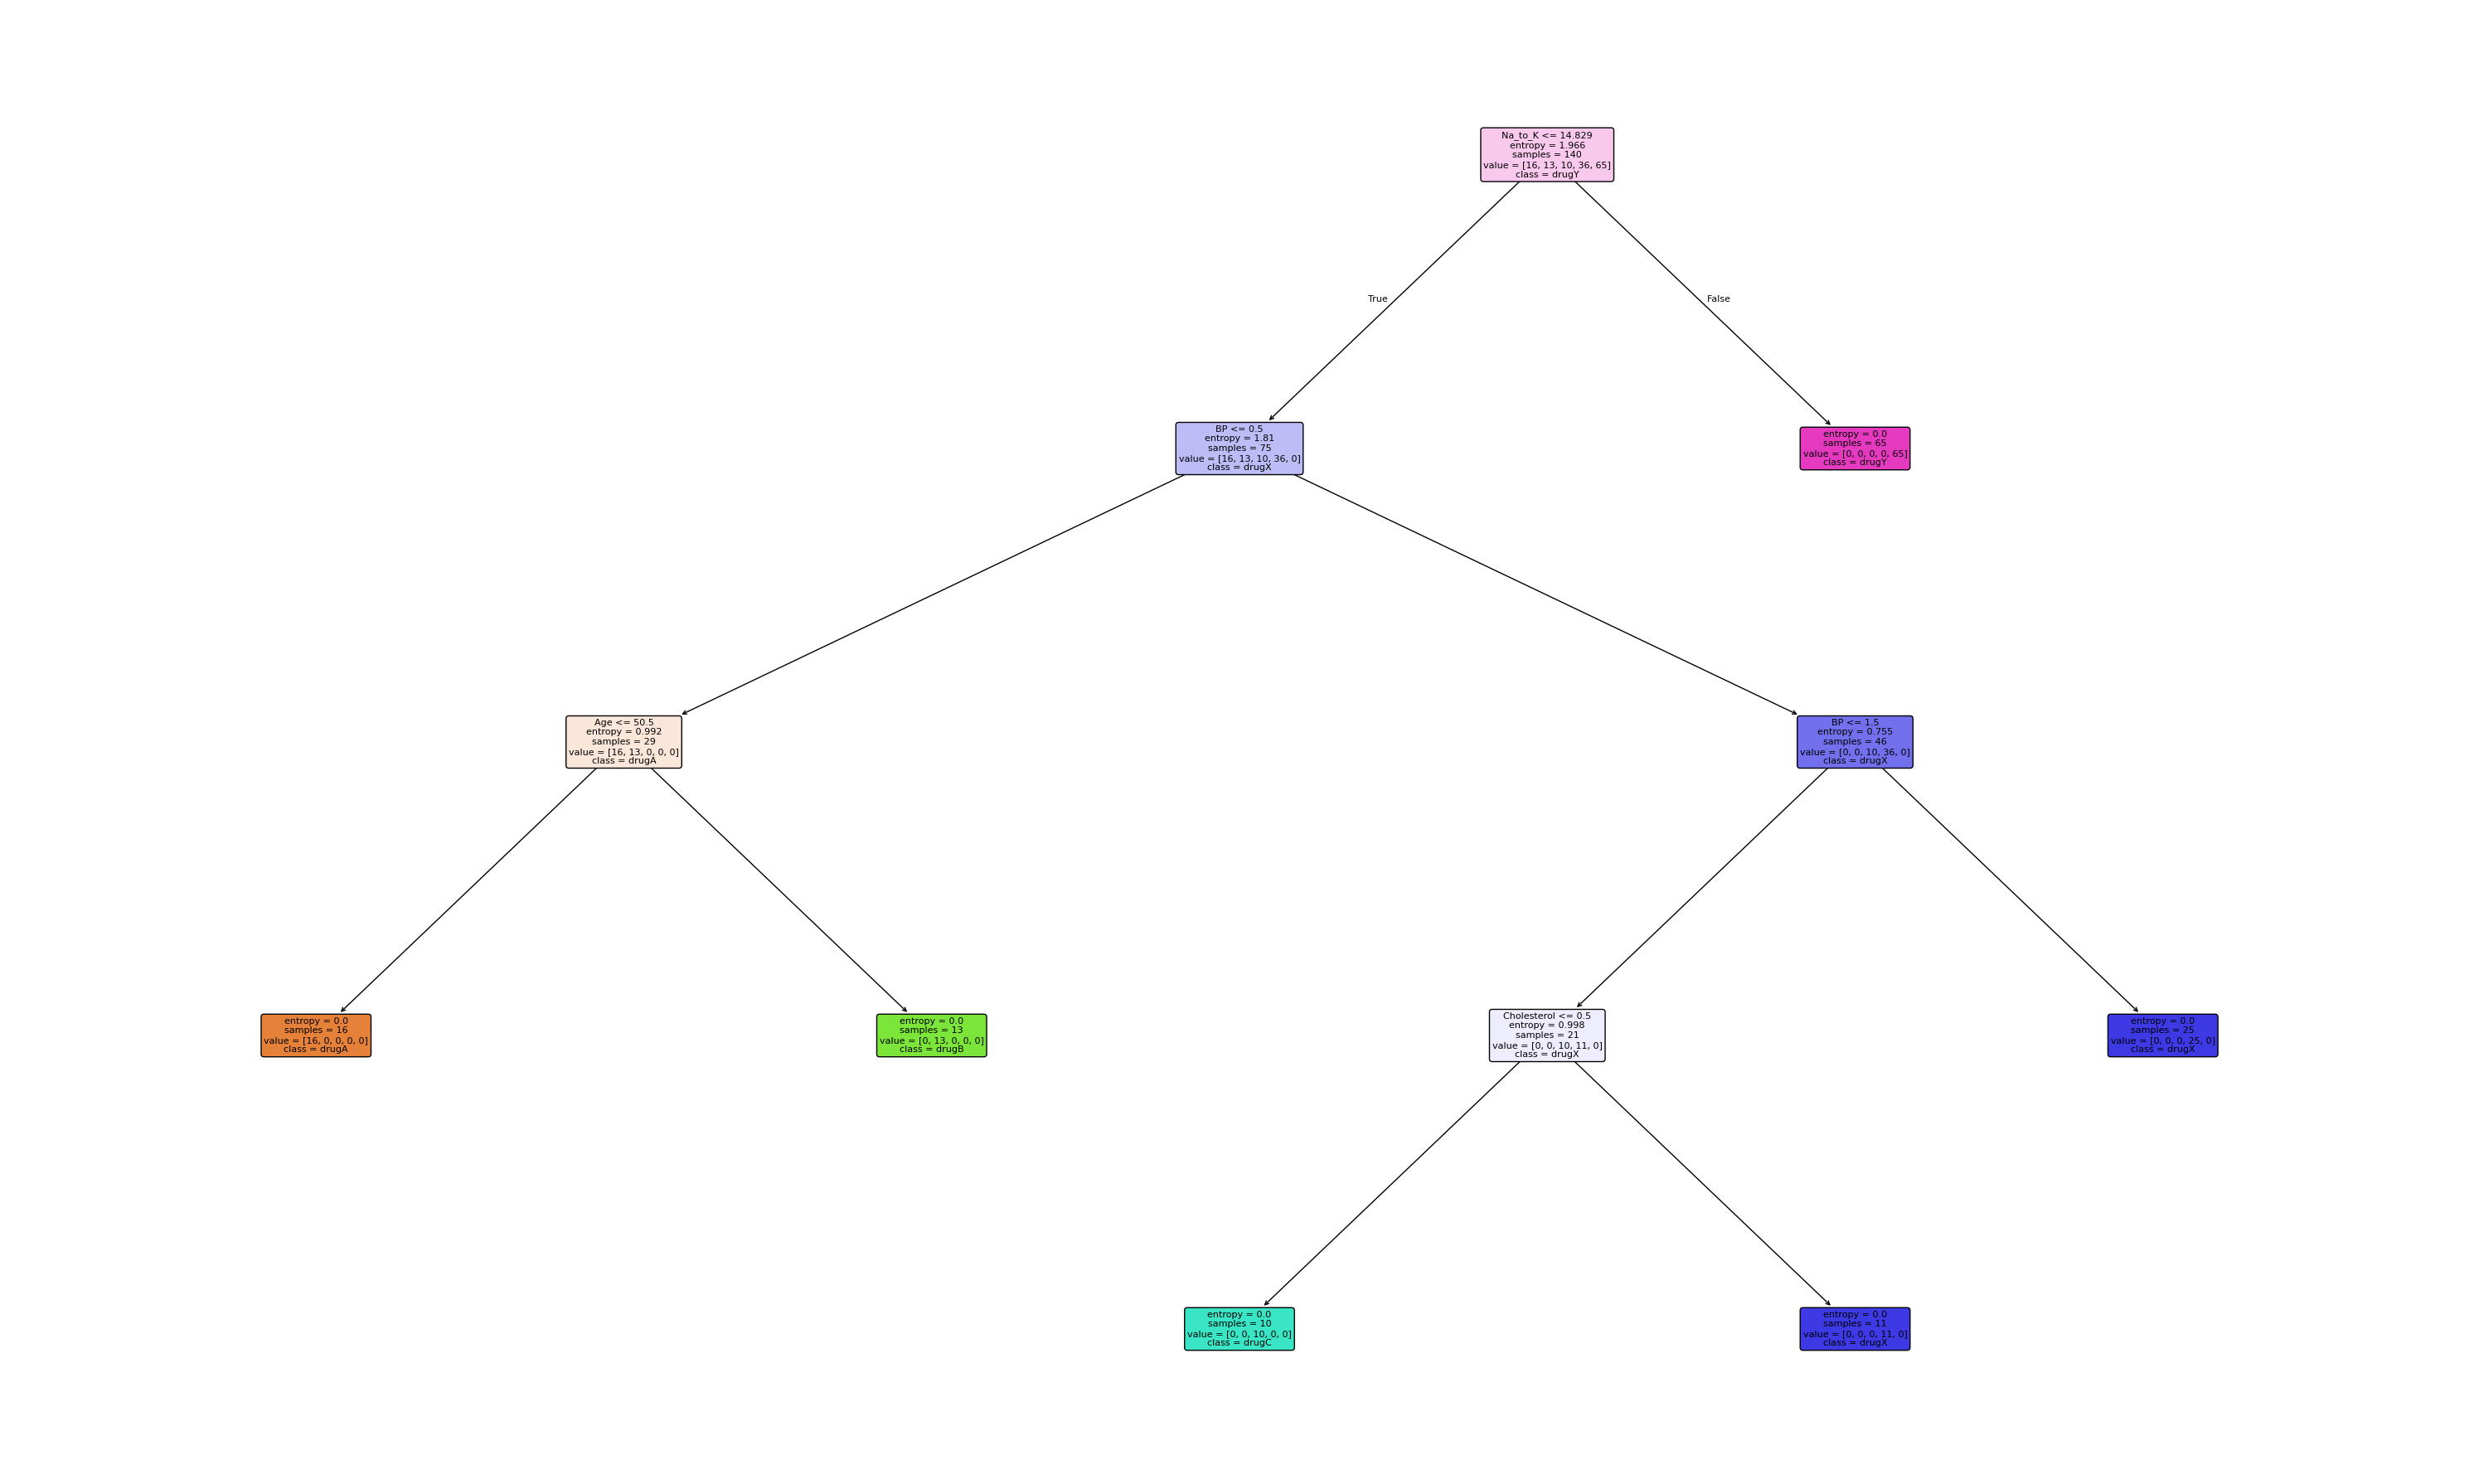

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = pd.read_csv('drug200.csv')

# Features & target
X = data.drop('Drug', axis=1)
y = data['Drug']

# Encode categorical columns
X['Sex'] = LabelEncoder().fit_transform(X['Sex'])
X['BP'] = LabelEncoder().fit_transform(X['BP'])
X['Cholesterol'] = LabelEncoder().fit_transform(X['Cholesterol'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train model
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)

print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(30, 18))     # VERY large canvas
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=8,                  # smaller text = less overlap
    max_depth=4                  # limit depth ONLY for plotting
)
plt.tight_layout()
plt.show()


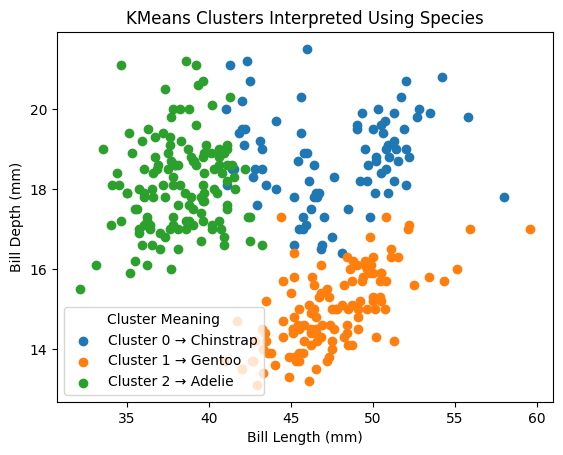

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("penguins.csv")

# Select features and species, drop missing values
data = df[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "species"
]].dropna()

X = data[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
data["Cluster"] = kmeans.fit_predict(X_scaled)

# Plot clusters with species meaning
plt.figure()

for cluster_id in sorted(data["Cluster"].unique()):
    cluster_data = data[data["Cluster"] == cluster_id]
    
    # Find dominant species in this cluster
    dominant_species = cluster_data["species"].mode()[0]
    
    plt.scatter(
        cluster_data["bill_length_mm"],
        cluster_data["bill_depth_mm"],
        label=f"Cluster {cluster_id} → {dominant_species}"
    )

plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.title("KMeans Clusters Interpreted Using Species")
plt.legend(title="Cluster Meaning")
plt.show()
